# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv'
df_hotels = pd.read_csv(url)
df_hotels.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1. The key stakeholders are hotel revenue managers, operations managers, marketing teams, and ownership.
2. Revenue managers want to set prices and overbooking levels that fill rooms without turning guests away. Operations managers need accurate guest counts to plan staffing and room assignments. Marketing wants to know which booking channels bring reliable guests, and ownership cares about the overall return of each property.
3. The business problem is that the hotels lose about 37% of bookings to cancellation, and they need to know which bookings are most likely to cancel so they can price, staff, and overbook with more confidence.

## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [4]:
print('--- DataFrame Info ---')
df_hotels.info()

print('\n--- Descriptive Statistics ---')
print(df_hotels.describe())

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64 

In [5]:
print('--- Number of Null Values per Column ---')
print(df_hotels.isnull().sum())

--- Number of Null Values per Column ---
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent           

In [7]:
print('\n--- Number of Duplicate Rows ---')
print(df_hotels.duplicated().sum())


--- Number of Duplicate Rows ---
31994


### Reflection:
1. Name at least one structure issue you’ve found (e.g., missing values, formatting problems).
2. How can you fix this structural issue?

### ✍️ Your Response: 🔧
1. There are three structural issues: missing values, duplicate rows, and unrealistic rates. The company column is missing for 94% of rows, and agent is missing for about 16,000. The country column is missing 488 values, and children is missing 4. The checks also flagged 31,994 duplicate rows, and adr has a negative minimum and a maximum of 5,400, which are not realistic nightly rates.

2. I would fill missing agent and company values with "None," because a blank there most likely means the guest booked without one. I would fill children with 0 and label missing countries as "Unknown." I would remove the negative adr value and the 5,400 outlier. Zero rates need a closer look, because some are complimentary stays and not errors. I would also be careful with the duplicates. The dataset has no booking ID, so two identical rows could be two real bookings and not an error.



## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64


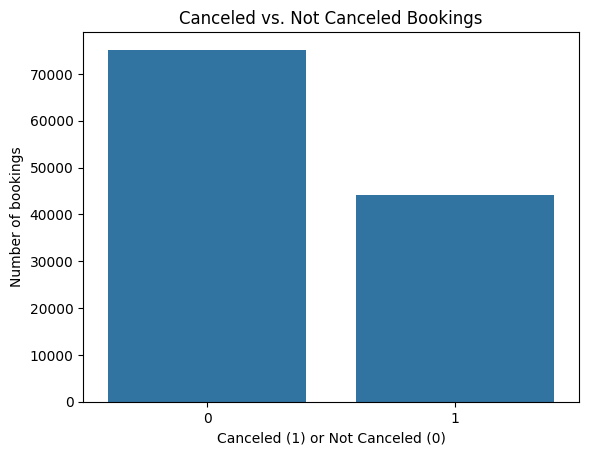

In [14]:
print(df_hotels['is_canceled'].value_counts(normalize=True))

sns.countplot(data=df_hotels, x='is_canceled')
plt.title('Canceled vs. Not Canceled Bookings')
plt.xlabel('Canceled (1) or Not Canceled (0)')
plt.ylabel('Number of bookings')
plt.show()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64
Zero or negative rates: 1960


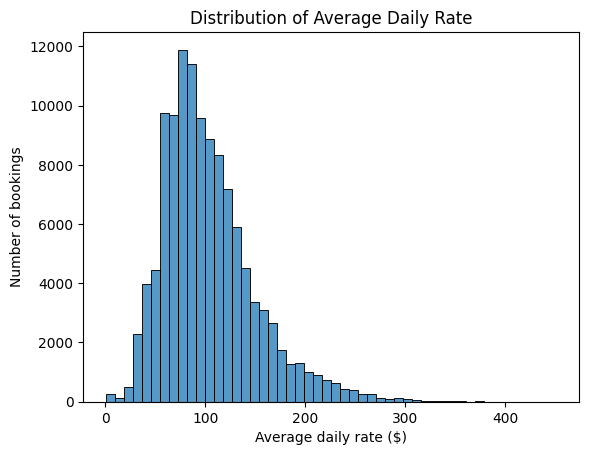

In [15]:
print(df_hotels['adr'].describe())
print('Zero or negative rates:', (df_hotels['adr'] <= 0).sum())

sns.histplot(df_hotels[(df_hotels['adr'] > 0) & (df_hotels['adr'] < 500)]['adr'], bins=50)
plt.title('Distribution of Average Daily Rate')
plt.xlabel('Average daily rate ($)')
plt.ylabel('Number of bookings')
plt.show()

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64


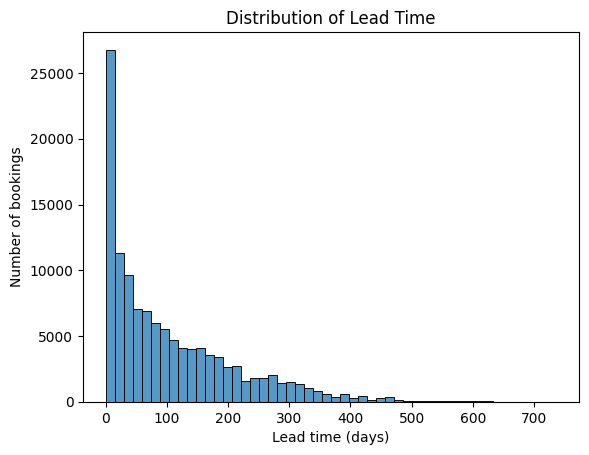

In [16]:
print(df_hotels['lead_time'].describe())

sns.histplot(df_hotels['lead_time'], bins=50)
plt.title('Distribution of Lead Time')
plt.xlabel('Lead time (days)')
plt.ylabel('Number of bookings')
plt.show()

### Reflection:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Variable 1 – Summary and insights:**  Variable 1 (is_canceled): About 37% of all bookings were canceled, and 63% went through. For a hotel, that means more than one in three bookings never turns into a stay.
- **Variable 2 – Summary and insights:**  Variable 2 (adr): The average daily rate has a median of about 95 dollars and a mean of about 102 dollars, so the distribution skews right. Most rates fall between 69 and 126 dollars. There are 1,960 zero or negative rates and a few extreme values, including one at 5,400 dollars. These should be cleaned before any pricing analysis.
- **Variable 3 – Summary and insights:**  Variable 3 (lead_time): Lead time is heavily right-skewed. The median guest books 69 days ahead, but the mean is 104 days, and the longest lead time is 737 days. Most guests book within a few months, while a long tail books far in advance.


## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

lead_bucket
0-7        0.096323
8-30       0.278639
31-90      0.376984
91-180     0.447105
181-365    0.554540
366+       0.676620
Name: is_canceled, dtype: float64
is_canceled
0     45.0
1    113.0
Name: lead_time, dtype: float64


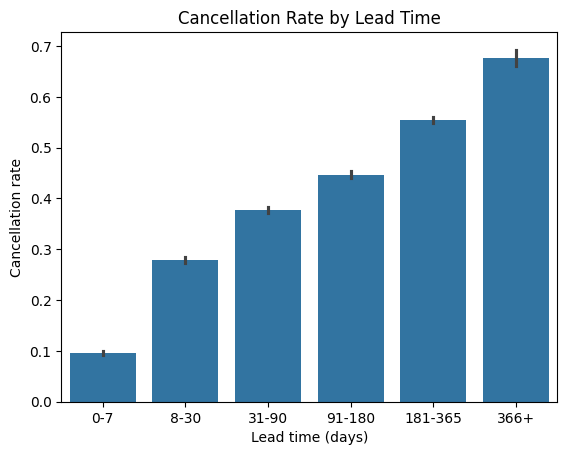

In [17]:
df_hotels['lead_bucket'] = pd.cut(df_hotels['lead_time'], [-1, 7, 30, 90, 180, 365, 800],
    labels=['0-7', '8-30', '31-90', '91-180', '181-365', '366+'])

print(df_hotels.groupby('lead_bucket', observed=True)['is_canceled'].mean())
print(df_hotels.groupby('is_canceled')['lead_time'].median())

sns.barplot(data=df_hotels, x='lead_bucket', y='is_canceled')
plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead time (days)')
plt.ylabel('Cancellation rate')
plt.show()

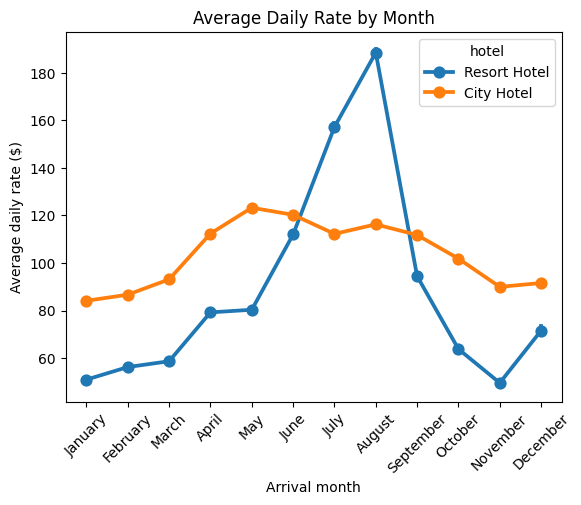

In [18]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
          'August', 'September', 'October', 'November', 'December']

sns.pointplot(data=df_hotels[(df_hotels['adr'] > 0) & (df_hotels['adr'] < 500)],
              x='arrival_date_month', y='adr', hue='hotel', order=months)
plt.title('Average Daily Rate by Month')
plt.xlabel('Arrival month')
plt.ylabel('Average daily rate ($)')
plt.xticks(rotation=45)
plt.show()

### Reflection:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧
- **Relationship 1:**  Relationship 1 (lead_time vs. is_canceled): Cancellation rises steadily with lead time. Bookings made within a week cancel about 10% of the time, and bookings made more than a year out cancel about 68% of the time. The median lead time for canceled bookings is 113 days, compared with 45 days for completed stays. Lead time is a strong early warning sign the hotel can see on the day of booking.
- **Relationship 2:**  Relationship 2 (adr by month and hotel): The two hotels price on different seasonal patterns. Resort Hotel rates rise from about 50 dollars in winter to about 189 dollars in August. City Hotel rates stay steadier, between about 84 and 123 dollars, with the peak in spring and early summer. The resort depends much more on a short summer season, and that raises the cost of every summer cancellation.

## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection:
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧
1. I chose the finding that longer lead times predict cancellations.
2. The main complexity is variability. Cancellation behavior shifts with season, hotel type, booking channel, and deposit policy, so one lead-time rule will not fit every booking.
3. Predictive analytics would help most, because a model using lead time, deposit type, and market segment could score each new booking by its risk of cancellation. Prescriptive analytics could then turn those scores into overbooking limits or deposit requirements.



## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### Reflection:
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. Three patterns stood out: cancellations are common, they rise sharply with lead time, and the Resort Hotel depends on a short summer peak.

2. These findings connect to the revenue manager's goal of filling rooms and the operations goal of accurate planning.

3. I recommend that the hotels require a partial deposit on bookings made more than 90 days out, especially for summer stays at the resort, so a cancellation still brings in some revenue. I also recommend setting overbooking levels by lead-time group.

4. This assignment relates to my learning outcome of building a Python workflow that cleans and categorizes messy data. The duplicate rows and invalid rates showed me that cleaning decisions influence the conclusions, and that I should check each result against the source before I trust it.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [ ]:
!jupyter nbconvert --to html "assignment_05_eda.ipynb"